In [1]:
# program taken from https://stanford.edu/~boyd/cvxbook/cvxbook_additional_exercises/
# ...and slightly adapted

# Also look at the description of exercise 22 on the exercise sheet!

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from cvxopt import matrix, solvers

In [2]:
# an auxiliary function interpreting three given arrays as red/green/blue values
# and showing the resulting image
def show_img(R,G,B):
  img = np.stack((np.array(R),np.array(G),np.array(B)), axis=2)
  # turn off ticks and labels of the figure
  plt.tick_params(
    axis='both', which='both', labelleft='off', labelbottom='off',
    bottom='off', top='off', right='off', left='off'
  )
  fig = plt.imshow(img)


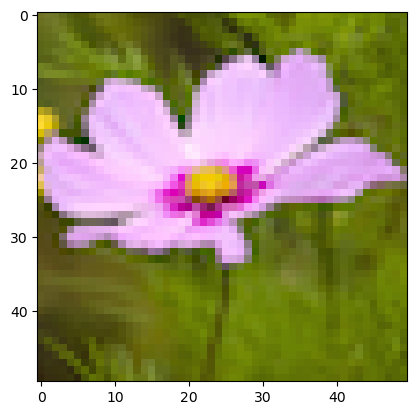

In [6]:
#read image
img = mpimg.imread("flower.png")
img = img[:,:,0:3]  # img is a triple of matrices, storing the intensity values for red, green and blue
m,n,_ = img.shape
plt.imshow(img)

# make into greyscale image
M = 0.299*img[:,:,0]+0.587*img[:,:,1]+0.114*img[:,:,2]

# record some color values which we will assume as known later for reconstruction
np.random.seed(0)
known_ind = np.where(np.random.rand(m,n) >= 0.90)
R_known = img[:,:,0]
G_known = img[:,:,1]
B_known = img[:,:,2]
R_known = R_known[known_ind]
G_known = G_known[known_ind]
B_known = B_known[known_ind]

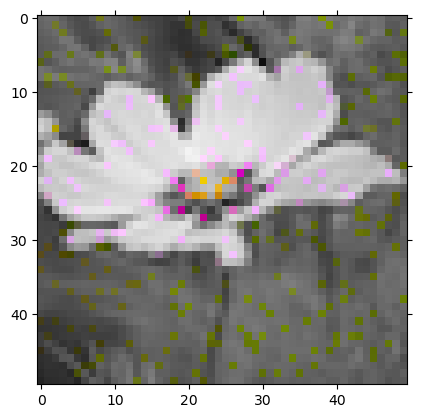

In [4]:
# sprinkle the greyscale picture with the pixels of known color 
R_given = np.copy(M);
R_given[known_ind] = R_known;
G_given = np.copy(M);
G_given[known_ind] = G_known;
B_given = np.copy(M);
B_given[known_ind] = B_known;

# show the picture that we are starting with for our reconstruction task
show_img(R_given, G_given, B_given)


     pcost       dcost       gap    pres   dres
 0:  1.7622e+02 -1.1082e+04  4e+04  2e+00  2e-13
 1:  1.8742e+02 -5.5562e+03  7e+03  1e-01  5e-14
 2:  1.5833e+02 -6.4834e+02  8e+02  1e-03  5e-14
 3:  1.3055e+02 -2.9502e+01  2e+02  2e-04  5e-14
 4:  1.2298e+02  6.7546e+01  6e+01  5e-05  5e-14
 5:  1.2078e+02  1.1196e+02  9e+00  5e-07  9e-14
 6:  1.2057e+02  1.1898e+02  2e+00  8e-08  2e-13
 7:  1.2055e+02  1.2043e+02  1e-01  2e-09  3e-13
 8:  1.2055e+02  1.2055e+02  3e-03  2e-11  6e-13


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5560134505982175e-25..1.0].


 9:  1.2055e+02  1.2055e+02  1e-04  5e-13  2e-13
Optimal solution found.


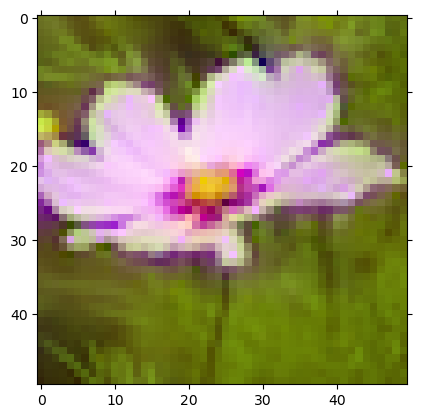

In [ ]:
# set up the matrices and vectors to feed into cvxopt.solvers.qp
# the names are chosen as in the API here:
#  http://cvxopt.org/userguide/coneprog.html#quadratic-programming


N = m * n
n_vars = 3 * N


flat_known_indices = known_ind[0] * n + known_ind[1]
num_known = len(flat_known_indices)


mask_unknown = np.ones(N, dtype=bool)
mask_unknown[flat_known_indices] = False
num_unknown = np.sum(mask_unknown)


adj = np.zeros((N, N))
for r in range(m):
    for c in range(n):
        idx = r * n + c
        # Right Neighbor
        if c + 1 < n:
            n_idx = r * n + (c + 1)
            adj[idx, n_idx] = 1; adj[n_idx, idx] = 1
        # Down Neighbor
        if r + 1 < m:
            n_idx = (r + 1) * n + c
            adj[idx, n_idx] = 1; adj[n_idx, idx] = 1


degree = np.diag(np.sum(adj, axis=1))
L = degree - adj


# We use 2.0 * L because the solver minimizes (1/2)xPx
P_block = 2.0 * L * np.eye(N) 
Z_block = np.zeros((N, N))
P = np.block([
    [P_block, Z_block, Z_block],
    [Z_block, P_block, Z_block],
    [Z_block, Z_block, P_block]
])

q = np.zeros(n_vars)


#x <= 1  AND  -x <= 0
G = np.vstack([np.eye(n_vars), -np.eye(n_vars)])
h = np.hstack([np.ones(n_vars), np.zeros(n_vars)])


A_gray_full = np.hstack([0.299 * np.eye(N), 0.587 * np.eye(N), 0.114 * np.eye(N)])
b_gray_full = M.flatten()


A_gray = A_gray_full[mask_unknown, :]
b_gray = b_gray_full[mask_unknown]


A_known_R = np.zeros((num_known, n_vars))
A_known_G = np.zeros((num_known, n_vars))
A_known_B = np.zeros((num_known, n_vars))


rows = np.arange(num_known)
A_known_R[rows, flat_known_indices] = 1         
A_known_G[rows, flat_known_indices + N] = 1     
A_known_B[rows, flat_known_indices + 2*N] = 1


A_known = np.vstack([A_known_R, A_known_G, A_known_B])
b_known = np.concatenate([R_known, G_known, B_known])


A = np.vstack([A_gray, A_known])
b = np.concatenate([b_gray, b_known])

# --- 4. SOLVE ---
# the cvxopt package has its own matrix class - this is what you need to feed into the qp solver 
my_P = matrix(P.astype(np.double))
my_q = matrix(q.astype(np.double))
my_G = matrix(G.astype(np.double))
my_h = matrix(h.astype(np.double))
my_A = matrix(A.astype(np.double))
my_b = matrix(b.astype(np.double))

# this is where the optimization problem is solved:
sol = solvers.qp(my_P, my_q, my_G, my_h, my_A, my_b)
# 'sol' is now a dictionary with several kinds of information
# the actual solution vector of values r_{ij}, g_{ij}, b_{ij} is the following:
sol['x']

# now repackage this solution vector into 3 matrices of size 50x50 encoding the red/green/blue values
vals = np.array(sol['x']).flatten()
R_reconstructed = vals[0:N].reshape(m, n)
G_reconstructed = vals[N:2*N].reshape(m, n)
B_reconstructed = vals[2*N:3*N].reshape(m, n)

# see what we have got
show_img(R_reconstructed, G_reconstructed, B_reconstructed)